### **BBC NEWS CLASSIFICATION - DATA EXPLORATION & EDA**

##### This notebook performs comprehensive exploratory data analysis on the BBC News dataset to understand its characteristics before model training.

#### Objectives: Understand the dataset structure, distribution, and characteristics

#### **Contents:**
##### 1. Dataset Loading & Overview
##### 2. Class Distribution Analysis
##### 3. Data Quality Assessment
##### 4. Sample Articles Review
##### 5. Word Frequency Analysis


##### Convert to a pandas DataFrame

In [2]:
import os
import pandas as pd

base_path = "bbc"  # path to the dataset root folder

data = []

for label in os.listdir(base_path):
    label_path = os.path.join(base_path, label)
    
    if os.path.isdir(label_path):
        for file_name in os.listdir(label_path):
            file_path = os.path.join(label_path, file_name)
            
            with open(file_path, "r", encoding="latin-1") as f:
                text = f.read()
                
            data.append({
                "text": text,
                "label": label
            })

df = pd.DataFrame(data)

df.head()

,text,label
0,Ad sales boost Time Warner profit\n\nQuarterly...,business
1,Dollar gains on Greenspan speech\n\nThe dollar...,business
2,Yukos unit buyer faces loan claim\n\nThe owner...,business
3,High fuel prices hit BA's profits\n\nBritish A...,business
4,Pernod takeover talk lifts Domecq\n\nShares in...,business


##### Save as CSV

In [3]:
df.to_csv("bbc_news.csv", index=False)

#### 1. Import Necessary Libraries

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

#### Load the BBC News Dataset

In [28]:
df = pd.read_csv("bbc_news.csv")

print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")

Dataset loaded successfully!
Shape: (2225, 2)


#### Dataset Overview

In [36]:
print("=" * 60)
print("BBC NEWS DATASET OVERVIEW")
print("=" * 60)
print(f"Total samples      : {len(df)}")
print(f"Number of features : {df.shape[1]}")
print(f"Number of classes  : {df['label'].nunique()}")
print(f"Classes            : {', '.join(df['label'].unique())}")
print("=" * 60)

BBC NEWS DATASET OVERVIEW
Total samples      : 2225
Number of features : 2
Number of classes  : 5
Classes            : business, entertainment, politics, sport, tech


In [41]:
# Display first few rows

print("First 5 rows of the dataset:")
df.head()

First 5 rows of the dataset:


,text,label
0,Ad sales boost Time Warner profit\n\nQuarterly...,business
1,Dollar gains on Greenspan speech\n\nThe dollar...,business
2,Yukos unit buyer faces loan claim\n\nThe owner...,business
3,High fuel prices hit BA's profits\n\nBritish A...,business
4,Pernod takeover talk lifts Domecq\n\nShares in...,business


In [47]:
# Dataset info

print("Dataset Information:\n")
df.info()

Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2225 entries, 0 to 2224
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    2225 non-null   object
 1   label   2225 non-null   object
dtypes: object(2)
memory usage: 34.9+ KB


In [49]:
# Basic statistics

print("Basic Statistics:")
df.describe(include='all')

Basic Statistics:


,text,label
count,2225,2225
unique,2127,5
top,Ray DVD beats box office takings\n\nOscar-nomi...,sport
freq,2,511


#### 2. Class Distribution Analysis

In [63]:
print("\n" + "=" * 60)
print("CLASS DISTRIBUTION")
print("=" * 60)

class_counts = df['label'].value_counts()
print(class_counts) #normal class counting

print("\nPercentage distribution:")
print(df['label'].value_counts(normalize=True) * 100) # class counting via proportion


CLASS DISTRIBUTION
label
sport            511
business         510
politics         417
tech             401
entertainment    386
Name: count, dtype: int64

Percentage distribution:
label
sport            22.966292
business         22.921348
politics         18.741573
tech             18.022472
entertainment    17.348315
Name: proportion, dtype: float64


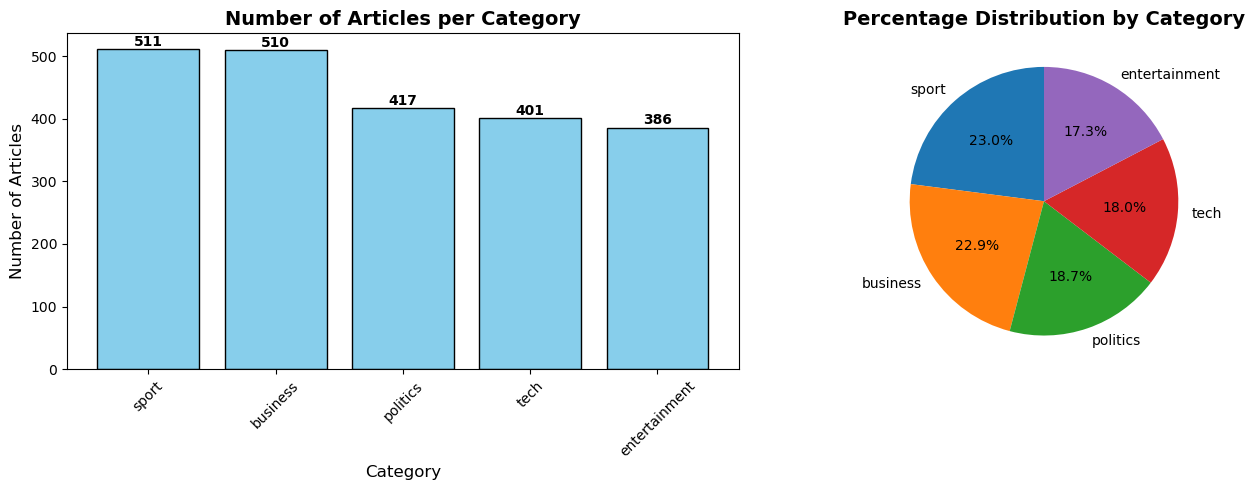

In [73]:
# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
axes[0].bar(class_counts.index, class_counts.values, color='skyblue', edgecolor='black')
axes[0].set_title('Number of Articles per Category', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Category', fontsize=12)
axes[0].set_ylabel('Number of Articles', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

# Add value labels on bars
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(class_counts.values, labels=class_counts.index, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Percentage Distribution by Category', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [75]:
# Check for class imbalance
max_class = class_counts.max()
min_class = class_counts.min()
imbalance_ratio = max_class / min_class

print(f"\nClass Imbalance Analysis:")
print(f"Largest class: {class_counts.idxmax()} ({max_class} samples)")
print(f"Smallest class: {class_counts.idxmin()} ({min_class} samples)")
print(f"Imbalance ratio: {imbalance_ratio:.2f}")

if imbalance_ratio < 1.5:
    print("Dataset is relatively balanced")
else:
    print("Dataset shows some imbalance")


Class Imbalance Analysis:
Largest class: sport (511 samples)
Smallest class: entertainment (386 samples)
Imbalance ratio: 1.32
Dataset is relatively balanced


#### 3. Data Quality Assessment

In [98]:
print("\n" + "=" * 60)
print("DATA QUALITY ASSESSMENT")
print("=" * 60)

# 1. Missing values
missing = df.isnull().sum().sum()
print(f"1. Missing Values: {missing}")
print("~ No missing values found" if missing == 0 else "~ Missing values detected")

# 2. Duplicate rows
duplicates = df.duplicated().sum()
print(f"\n2. Duplicate Rows: {duplicates}")
print("~ No duplicate rows found" if duplicates == 0 else "~ Duplicates found")

# 3. Empty text fields
empty_texts = df['text'].str.strip().eq('').sum()
print(f"\n3. Empty Text Fields: {empty_texts}")
print("~ No empty text fields" if empty_texts == 0 else "~ Empty text entries found")

# 4. Noisy content (URLs, HTML, long numbers)
noise_patterns = r"http|www|<|>|\d{10,}"
noisy_texts = df['text'].str.contains(noise_patterns, regex=True).sum()
print(f"\n4. Articles with URLs/HTML: {noisy_texts}")
print("~ Minimal noise in dataset" if noisy_texts < 10 else "~ Significant noise detected")


DATA QUALITY ASSESSMENT
1. Missing Values: 0
~ No missing values found

2. Duplicate Rows: 98
~ Duplicates found

3. Empty Text Fields: 0
~ No empty text fields

4. Articles with URLs/HTML: 4
~ Minimal noise in dataset


#### 4. Sample Articles Review

In [109]:
print("\n" + "=" * 60)
print("SAMPLE ARTICLES FROM EACH CATEGORY")
print("=" * 60)

for category in sorted(df['label'].unique()):
    sample = df[df['label'] == category].iloc[0]

    print(f"\n{'=' * 60}")
    print(f"Category: {category.upper()}")
    print(f"Word Count: {sample['word_count']}")
    print("\nText Preview (first 300 characters):")
    print(sample['text'][:300] + "...")


SAMPLE ARTICLES FROM EACH CATEGORY

Category: BUSINESS
Word Count: 421

Text Preview (first 300 characters):
Ad sales boost Time Warner profit

Quarterly profits at US media giant TimeWarner jumped 76% to $1.13bn (Â£600m) for the three months to December, from $639m year-earlier.

The firm, which is now one of the biggest investors in Google, benefited from sales of high-speed internet connections and high...

Category: ENTERTAINMENT
Word Count: 190

Text Preview (first 300 characters):
Gallery unveils interactive tree

A Christmas tree that can receive text messages has been unveiled at London's Tate Britain art gallery.

The spruce has an antenna which can receive Bluetooth texts sent by visitors to the Tate. The messages will be "unwrapped" by sculptor Richard Wentworth, who is ...

Category: POLITICS
Word Count: 450

Text Preview (first 300 characters):
Labour plans maternity pay rise

Maternity pay for new mothers is to rise by Â£1,400 as part of new proposals announced by the Tr

#### 5. Word Frequency Analysis

In [152]:
import re
from collections import Counter

# Function to extract top words
def get_top_words(texts, n=20, remove_stopwords=True):
    stopwords = {
        'the','a','an','and','or','but','in','on','at','to','for','of','with','by',
        'from','as','is','was','are','were','be','been','have','has','had','do','does',
        'did','will','would','could','should','may','might','must','can','this','that',
        'these','those','it','its'
    }

    words = re.findall(r'\b[a-z]{3,}\b', ' '.join(texts).lower())

    if remove_stopwords:
        words = [w for w in words if w not in stopwords]

    return Counter(words).most_common(n)

In [154]:
print("\n" + "=" * 60)
print("TOP 20 MOST FREQUENT WORDS (OVERALL)")
print("=" * 60)

for word, count in get_top_words(df['text']):
    print(f"{word:15s}: {count}")


TOP 20 MOST FREQUENT WORDS (OVERALL)
said           : 7255
not            : 3484
they           : 3085
his            : 3026
which          : 2585
their          : 2408
more           : 2338
year           : 2309
also           : 2156
who            : 2091
people         : 2045
new            : 1978
one            : 1892
there          : 1863
about          : 1802
out            : 1701
after          : 1681
than           : 1620
all            : 1603
you            : 1520


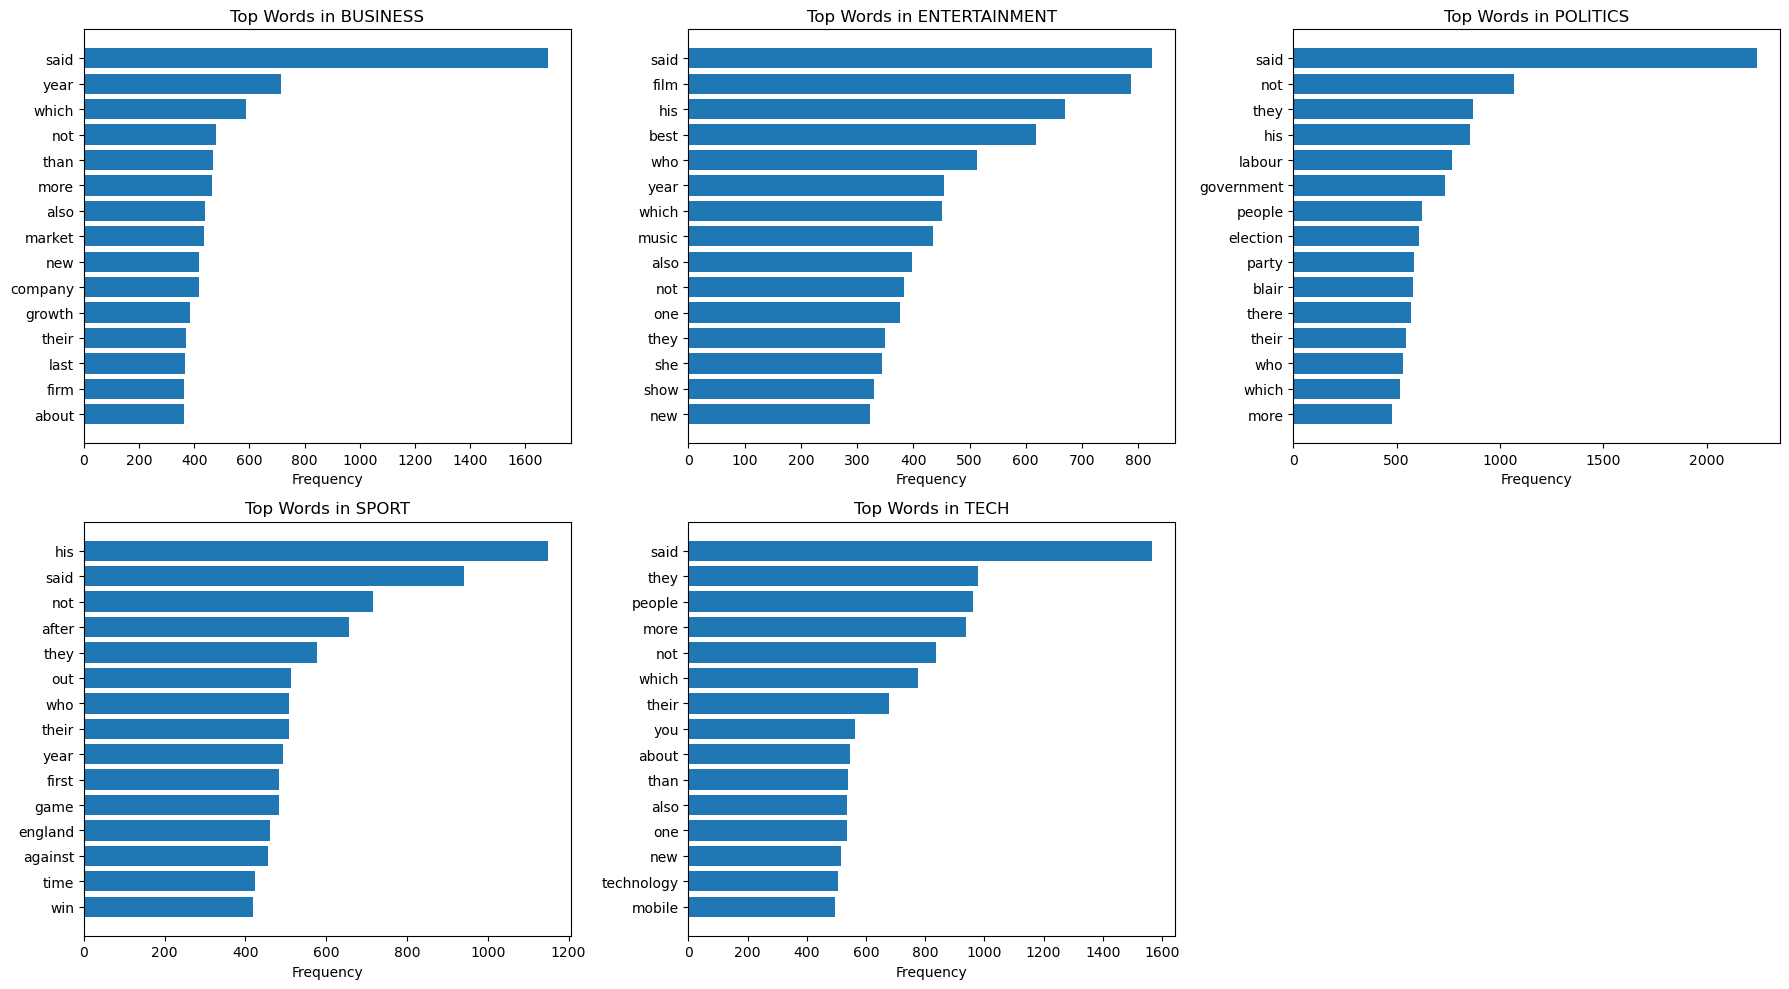

In [156]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, category in zip(axes, sorted(df['label'].unique())):
    texts = df.loc[df['label'] == category, 'text']
    words, counts = zip(*get_top_words(texts, n=15))

    ax.barh(words, counts)
    ax.set_title(f"Top Words in {category.upper()}")
    ax.set_xlabel("Frequency")
    ax.invert_yaxis()

# Hide unused subplot
for ax in axes[len(df['label'].unique()):]:
    ax.axis('off')

plt.tight_layout()
plt.show()
